# Sistemas de EDOs rígidos con una discontinuidad (salto): por qué un método explícito oscila y un método implícito no

**Curso:** Métodos numéricos, pregrado — tema: sistemas de EDOs, rigidez (*stiffness*), estabilidad absoluta de métodos numéricos, métodos implícitos.

## Objetivo pedagógico

Vas a comprobar con tus propios ojos (y tus propios números) un fenómeno clásico:

> Cuando un sistema de EDOs es **rígido** (tiene autovalores de magnitudes muy distintas) y además la forzante tiene un **salto** (una discontinuidad tipo escalón), el salto "golpea" al sistema y excita **todos** sus modos, incluido el modo rápido. Si el método numérico es **explícito** y el paso `h` no es lo bastante pequeño para ese modo rápido, la solución numérica **oscila con amplitud creciente** justo después del salto — aunque el sistema físico real no oscile en absoluto. Un método **implícito** (Euler implícito, Radau, BDF) no tiene ese problema: es estable para cualquier `h`.

No vamos a usar un ejemplo abstracto: vamos a modelar un sistema térmico de dos partes con capacidades térmicas muy distintas, exactamente como podrías encontrar en un problema de ingeniería real.

## El fenómeno en una frase

Antes del salto, todo está en reposo (nada se mueve, cualquier método se ve "estable" porque no hay nada que integrar). El salto activa de golpe la dinámica rápida, y ahí es donde el paso de tiempo `h` se pone a prueba de verdad.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=4, suppress=True)


## 1. Teoría breve

### 1.1 Sistema rígido (*stiff*)

Un sistema lineal $\dot{\mathbf{y}} = A\mathbf{y} + \mathbf{b}(t)$ es **rígido** cuando los autovalores de $A$ tienen magnitudes muy distintas entre sí. Cuando existen dos autovalores $\lambda_{rápido}$ y $\lambda_{lento}$ con $\operatorname{Re}(\lambda_i)\neq 0$, se suele definir el **número de rigidez** como el cociente $S = |\lambda_{rápido}|/|\lambda_{lento}|\gg 1$.

En nuestro ejemplo va a pasar algo particular: como no hay pérdidas de calor hacia el ambiente (solo intercambio interno entre las dos masas), la energía total se conserva y **uno de los dos autovalores es exactamente cero** (el modo que corresponde a "toda la energía junta, sin redistribuirse" ni crece ni decae). En ese caso el número de rigidez formal se va a infinito; lo relevante para el análisis de estabilidad es comparar el autovalor rápido (grande y negativo) contra la escala de tiempo lenta del proceso, $\tau_2 = C_2/UA$, que sí determina cuánto tarda el sistema en evolucionar de forma visible.

### 1.2 Estabilidad absoluta de un método explícito

Para la ecuación de prueba $\dot y = \lambda y$ (con $\operatorname{Re}(\lambda) < 0$), cada método de un paso produce $y_{n+1} = R(h\lambda)\, y_n$, donde $R$ es la **función de estabilidad** del método. El método es estable si $|R(h\lambda)| \le 1$.

- **Euler explícito:** $R(z) = 1 + z$. Es estable solo si $-2 \le z \le 0$, es decir, $h \le 2/|\lambda|$. Además, para $-2 < z < 0$ pero $z<-1$ (es decir $1<h|\lambda|<2$), $R(z)$ es **negativo**: la solución numérica oscila cambiando de signo en cada paso, aunque todavía decae. Si $z<-2$, $|R(z)|>1$ y esa oscilación **crece sin límite**.
- **RK4 explícito (paso fijo):** $R(z) = 1+z+\tfrac{z^2}{2}+\tfrac{z^3}{6}+\tfrac{z^4}{24}$. Su región de estabilidad sobre el eje real llega hasta $z\approx-2.785$, pero (a diferencia de Euler) $R(z)$ nunca baja de $-1$ para $z$ real: cuando RK4 se vuelve inestable, **diverge de forma monótona**, no oscilante. Es un buen recordatorio de que *cada método explícito falla a su manera*, pero **todos** están limitados por el autovalor rápido.
- **Euler implícito (backward Euler):** $R(z) = \dfrac{1}{1-z}$. Para cualquier $z$ con $\operatorname{Re}(z) \le 0$, $|R(z)| \le 1$: es **incondicionalmente estable** (se dice que es *A-estable*). Nunca oscila, sin importar qué tan grande sea `h`.
- **Radau IIA / BDF** (los solvers `'Radau'` y `'BDF'` de `scipy.integrate.solve_ivp`): son métodos implícitos de orden superior, también con excelentes propiedades de estabilidad para sistemas rígidos (Radau es A-estable; BDF hasta orden 6 es *stiffly stable*). Son la elección estándar de la industria para sistemas rígidos.

### 1.3 El papel del salto

Si la forzante $\mathbf{b}(t)$ tiene un salto en $t_0$, justo en $t_0$ el sistema recibe una entrada tipo impulso en derivada: **todos los modos se excitan**, incluido el rápido. Lejos del salto, si la solución varía lentamente, un método explícito puede "verse" estable con un `h` grande simplemente porque no hay mucho que resolver — el salto es el único momento en que el paso realmente se pone a prueba. Por eso vas a ver que el mismo `h`, que en apariencia "funciona" antes del salto, produce oscilaciones o directamente diverge apenas ocurre el salto.


## 2. El problema físico: un calentador de baja capacidad térmica dentro de un baño

Imagina un pequeño elemento calefactor eléctrico (una resistencia delgada, capacidad térmica $C_1$ muy **pequeña**) sumergido en un baño de líquido de gran volumen (capacidad térmica $C_2$ muy **grande**), acoplados por un coeficiente de transferencia $UA$. En $t=0$ ambos están a temperatura ambiente. En $t = t_0 = 5\,\text{s}$ se **enciende abruptamente** el calentador (un escalón de potencia $Q_0$), como lo haría un relé o un termostato mecánico.

$$
C_1 \frac{dT_1}{dt} = Q(t) - UA\,(T_1 - T_2), \qquad
C_2 \frac{dT_2}{dt} = UA\,(T_1 - T_2),
$$

$$
Q(t) = \begin{cases} 0 & t < t_0 \\ Q_0 & t \ge t_0\end{cases}
\qquad \text{(escalón de Heaviside)}
$$

En forma matricial, $\dot{\mathbf y} = A\mathbf y + \mathbf b(t)$ con $\mathbf y = (T_1, T_2)^T$:

$$
A = \begin{pmatrix} -UA/C_1 & UA/C_1 \\ UA/C_2 & -UA/C_2 \end{pmatrix}, \qquad
\mathbf b(t) = \begin{pmatrix} Q(t)/C_1 \\ 0 \end{pmatrix}.
$$

Como $C_1 \ll C_2$, el elemento calefactor reacciona casi instantáneamente (constante de tiempo $\tau_1 = C_1/UA$ muy pequeña) mientras el baño reacciona muy lentamente ($\tau_2 = C_2/UA$ grande). Esa diferencia de escalas de tiempo es exactamente lo que hace rígido al sistema.


In [2]:
# --- Parametros fisicos ---
UA = 50.0     # W/K   coeficiente global de transferencia de calor (conductancia)
C1 = 0.05     # J/K   capacidad termica del elemento calefactor (PEQUENA -> rapida)
C2 = 500.0    # J/K   capacidad termica del bano (GRANDE -> lenta)
Q0 = 100.0    # W     potencia del calentador una vez encendido
t0_jump = 5.0 # s     instante en que se enciende el calentador (el "salto")
T_amb = 20.0  # C     temperatura inicial (ambiente)
t_final = 20.0

A = np.array([[-UA/C1,  UA/C1],
              [ UA/C2, -UA/C2]])

def Q(t):
    '''Forzante tipo escalon (Heaviside): el salto del problema.'''
    return 0.0 if t < t0_jump else Q0

def rhs(t, y):
    T1, T2 = y
    dT1 = (Q(t) - UA*(T1 - T2)) / C1
    dT2 = (UA*(T1 - T2)) / C2
    return [dT1, dT2]

y0 = [T_amb, T_amb]

eigvals = np.linalg.eigvals(A)
tau1, tau2 = C1/UA, C2/UA
lam_fast = np.max(np.abs(eigvals))
print(f"Autovalores de A: {eigvals}")
print(f"Constante de tiempo rapida  tau1 = C1/UA = {tau1:.4g} s   (asociada al autovalor grande, {-lam_fast:.1f} 1/s)")
print(f"Constante de tiempo lenta   tau2 = C2/UA = {tau2:.4g} s   (asociada al segundo autovalor, que aqui es EXACTAMENTE 0:")
print("   el sistema no tiene perdidas de calor al ambiente, solo intercambio interno T1<->T2,")
print("   asi que la energia total se conserva y ese modo ni crece ni decae -- por eso el 2do autovalor es 0.)")
print(f"Relacion de escalas de tiempo tau2/tau1 = {tau2/tau1:.3e}  (esto es lo que hace 'rigido' al sistema)")
print(f"|lambda_rapido| = {lam_fast:.2f} 1/s  ->  h_critico Euler explicito = 2/|lambda| = {2/lam_fast:.5f} s")


Autovalores de A: [-1000.1     0. ]
Constante de tiempo rapida  tau1 = C1/UA = 0.001 s   (asociada al autovalor grande, -1000.1 1/s)
Constante de tiempo lenta   tau2 = C2/UA = 10 s   (asociada al segundo autovalor, que aqui es EXACTAMENTE 0:
   el sistema no tiene perdidas de calor al ambiente, solo intercambio interno T1<->T2,
   asi que la energia total se conserva y ese modo ni crece ni decae -- por eso el 2do autovalor es 0.)
Relacion de escalas de tiempo tau2/tau1 = 1.000e+04  (esto es lo que hace 'rigido' al sistema)
|lambda_rapido| = 1000.10 1/s  ->  h_critico Euler explicito = 2/|lambda| = 0.00200 s


## 3. Solución de referencia de alta precisión

Antes de comparar métodos, generamos una solución "casi exacta" con un integrador implícito (Radau) y tolerancias muy estrictas. La usaremos como referencia para medir el error de los demás métodos.


Solucion de referencia: 835 pasos, 5813 evaluaciones de la funcion RHS


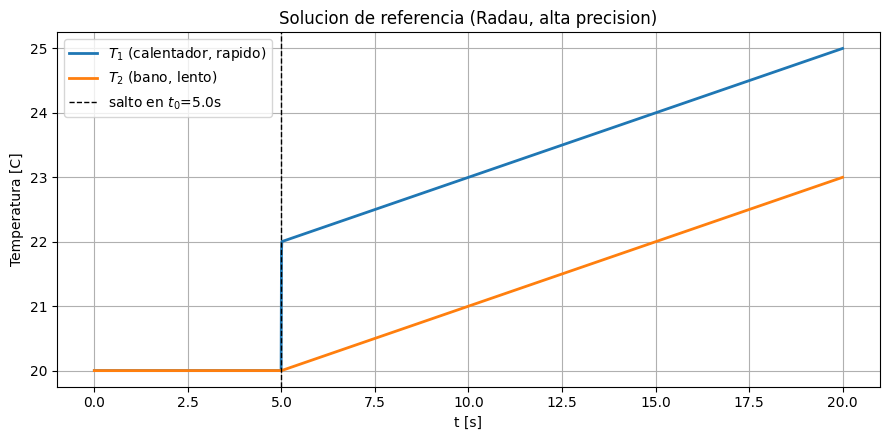

In [3]:
sol_ref = solve_ivp(rhs, [0, t_final], y0, method='Radau',
                     max_step=0.05, rtol=1e-11, atol=1e-13, dense_output=True)
print(f"Solucion de referencia: {len(sol_ref.t)} pasos, {sol_ref.nfev} evaluaciones de la funcion RHS")

t_plot = np.linspace(0, t_final, 2000)
y_ref = sol_ref.sol(t_plot)

fig, ax = plt.subplots()
ax.plot(t_plot, y_ref[0], label='$T_1$ (calentador, rapido)', lw=2)
ax.plot(t_plot, y_ref[1], label='$T_2$ (bano, lento)', lw=2)
ax.axvline(t0_jump, color='k', ls='--', lw=1, label=f'salto en $t_0$={t0_jump}s')
ax.set_xlabel('t [s]'); ax.set_ylabel('Temperatura [C]')
ax.set_title('Solucion de referencia (Radau, alta precision)')
ax.legend(); plt.tight_layout(); plt.show()


Nota cómo $T_1$ prácticamente "salta" a su valor de equilibrio apenas se enciende el calentador (dinámica rápida), mientras que $T_2$ apenas empieza a subir con una pendiente suave (dinámica lenta). Esa subida casi vertical de $T_1$ es la que un método explícito con paso grande no logra resolver limpiamente.

## 4. Euler explícito de paso fijo: aquí aparecen las oscilaciones

Implementamos Euler explícito "a mano" con paso constante `h`, y lo probamos con varios valores de `h` alrededor del paso crítico teórico $h_{crit} = 2/|\lambda_{rápido}|$.


In [4]:
def euler_explicito(rhs, t_span, y0, h, blowup=1e12):
    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    ts = np.linspace(t0, t0 + n*h, n + 1)
    ys = np.zeros((n + 1, len(y0)))
    ys[0] = y0
    for i in range(n):
        if not np.all(np.isfinite(ys[i])) or np.max(np.abs(ys[i])) > blowup:
            ys[i+1:] = np.nan
            break
        ys[i+1] = ys[i] + h*np.array(rhs(ts[i], ys[i]))
    return ts, ys
# (docstrings omitted in helper functions below to keep this build script simple)

h_crit = 2 / lam_fast
print(f"h_critico (Euler explicito) = {h_crit:.5f} s\n")

casos_h = {
    'h = 0.0005 s  (muy por debajo del critico)': 0.0005,
    'h = 0.0015 s  (por debajo, pero con oscilacion amortiguada)': 0.0015,
    'h = 0.0021 s  (justo por encima del critico)': 0.0021,
    'h = 0.0030 s  (bien por encima: diverge)': 0.0030,
}

resultados_euler = {}
for etiqueta, h in casos_h.items():
    ts, ys = euler_explicito(rhs, [0, t_final], y0, h)
    resultados_euler[etiqueta] = (ts, ys, h)
    max_abs = np.nanmax(np.abs(ys[:,0]))
    print(f"{etiqueta:55s}  h*|lambda|={h*lam_fast:5.2f}   max|T1| alcanzado = {max_abs:.3e} C")


h_critico (Euler explicito) = 0.00200 s



h = 0.0005 s  (muy por debajo del critico)               h*|lambda|= 0.50   max|T1| alcanzado = 2.500e+01 C
h = 0.0015 s  (por debajo, pero con oscilacion amortiguada)  h*|lambda|= 1.50   max|T1| alcanzado = 2.500e+01 C
h = 0.0021 s  (justo por encima del critico)             h*|lambda|= 2.10   max|T1| alcanzado = 1.093e+12 C
h = 0.0030 s  (bien por encima: diverge)                 h*|lambda|= 3.00   max|T1| alcanzado = 1.106e+12 C


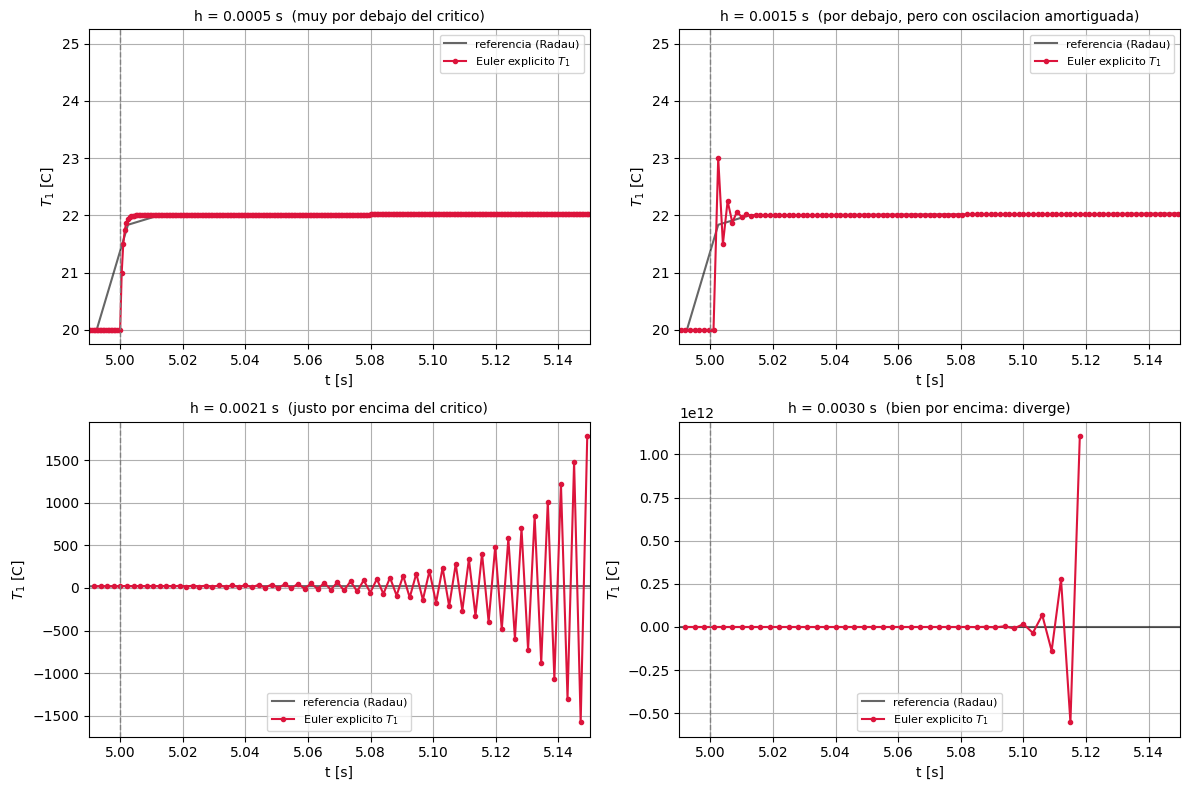

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for ax, (etiqueta, (ts, ys, h)) in zip(axes.flat, resultados_euler.items()):
    ventana = (ts >= t0_jump - 0.01) & (ts <= t0_jump + 0.15)
    ax.plot(t_plot, y_ref[0], 'k-', lw=1.5, alpha=0.6, label='referencia (Radau)')
    ax.plot(ts[ventana], ys[ventana, 0], 'o-', ms=3, color='crimson', label='Euler explicito $T_1$')
    ax.axvline(t0_jump, color='gray', ls='--', lw=1)
    ax.set_xlim(t0_jump - 0.01, t0_jump + 0.15)
    ax.set_title(etiqueta, fontsize=10)
    ax.set_xlabel('t [s]'); ax.set_ylabel('$T_1$ [C]')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Lo que deberías ver:**

- Con `h = 0.0005 s` (bien por debajo del crítico): la curva de Euler prácticamente se superpone a la referencia, sin ningún rastro de oscilación.
- Con `h = 0.0015 s`: aparecen oscilaciones que cambian de signo en cada paso, pero **se amortiguan** (siguen siendo $|R(h\lambda)|<1$) — el método sigue siendo estable, aunque ya "tiembla".
- Con `h = 0.0021 s` (apenas por encima de $h_{crit}$): la oscilación **crece** en cada paso.
- Con `h = 0.0030 s`: la oscilación crece tan rápido que en pocos pasos $T_1$ toma valores completamente irreales (positivos y negativos enormes, sin sentido físico) — el método ha divergido.

En los cuatro casos, **antes** del salto ($t<5$s) la solución de Euler es perfecta (porque no hay nada que integrar: todo está en reposo). El salto es el que "activa" la inestabilidad.


## 5. RK4 explícito de paso fijo: falla distinto, pero también falla

RK4 tiene una región de estabilidad más grande que Euler, pero como vimos en la teoría, su función de amplificación $R(z)$ **nunca es menor que $-1$** para $z$ real: cuando se vuelve inestable, lo hace de forma **monótona** (sin alternar signo), no oscilante. Aun así, sigue estando limitado por el mismo autovalor rápido.


In [6]:
def rk4_paso_fijo(rhs, t_span, y0, h, blowup=1e12):
    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    ts = np.linspace(t0, t0 + n*h, n + 1)
    ys = np.zeros((n + 1, len(y0)))
    ys[0] = y0
    for i in range(n):
        t, y = ts[i], ys[i]
        if not np.all(np.isfinite(y)) or np.max(np.abs(y)) > blowup:
            ys[i+1:] = np.nan
            break
        k1 = np.array(rhs(t, y))
        k2 = np.array(rhs(t + h/2, y + h/2*k1))
        k3 = np.array(rhs(t + h/2, y + h/2*k2))
        k4 = np.array(rhs(t + h,   y + h*k3))
        ys[i+1] = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return ts, ys

h_crit_rk4 = 2.785 / lam_fast
print(f"h_critico aproximado (RK4, real) = {h_crit_rk4:.5f} s")

for h in [0.0015, 0.0035]:
    ts, ys = rk4_paso_fijo(rhs, [0, t_final], y0, h)
    print(f"\nh={h}  (h*|lambda|={h*lam_fast:.2f})")
    ventana = (ts >= t0_jump) & (ts <= t0_jump + 0.02)
    for t, T1 in zip(ts[ventana], ys[ventana, 0]):
        print(f"  t={t:.4f}  T1={T1:10.3f}")


h_critico aproximado (RK4, real) = 0.00278 s



h=0.0015  (h*|lambda|=1.50)
  t=5.0010  T1=    21.563
  t=5.0025  T1=    21.881
  t=5.0040  T1=    21.968
  t=5.0055  T1=    21.992
  t=5.0070  T1=    21.999
  t=5.0085  T1=    22.001
  t=5.0100  T1=    22.001
  t=5.0115  T1=    22.002
  t=5.0130  T1=    22.002
  t=5.0145  T1=    22.003
  t=5.0160  T1=    22.003
  t=5.0175  T1=    22.003
  t=5.0190  T1=    22.003

h=0.0035  (h*|lambda|=3.50)
  t=5.0015  T1=    21.167
  t=5.0050  T1=    19.724
  t=5.0085  T1=    15.779
  t=5.0120  T1=     4.996
  t=5.0155  T1=   -24.474
  t=5.0190  T1=  -105.017


Observa que con `h = 0.0035 s` (por encima de su límite de estabilidad) RK4 **no oscila**: simplemente se dispara hacia valores cada vez más negativos, de forma monótona. Es la misma inestabilidad (el mismo autovalor rápido sin resolver), pero con una "firma" numérica distinta según la función de amplificación de cada método. **La lección importante:** no existe un método explícito de paso fijo que se salve de este problema — todos tienen un límite ligado a $|\lambda_{rápido}|$, solo cambia *cómo* fallan.

## 6. Euler implícito (backward Euler): sin oscilaciones, para cualquier `h`

Como el sistema es lineal, cada paso de Euler implícito se reduce a resolver un sistema lineal pequeño: $(I - hA)\,\mathbf y_{n+1} = \mathbf y_n + h\,\mathbf b(t_{n+1})$.


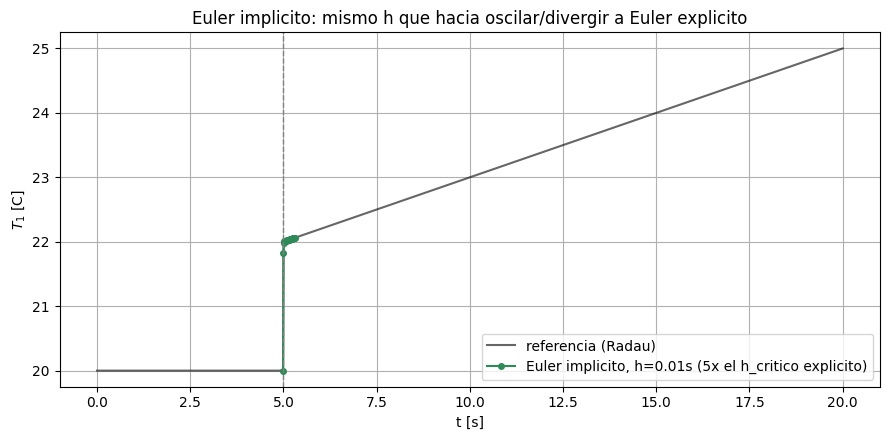

Pasos usados: 2000
Error maximo (vs referencia): 1.8198 C  -- sin ninguna oscilacion


In [7]:
def euler_implicito(A, b_of_t, t_span, y0, h):
    t0, tf = t_span
    n = int(np.ceil((tf - t0) / h))
    ts = np.linspace(t0, t0 + n*h, n + 1)
    ys = np.zeros((n + 1, len(y0)))
    ys[0] = y0
    I = np.eye(len(y0))
    M = I - h*A                      # misma matriz en todos los pasos: se factoriza una sola vez
    from scipy.linalg import lu_factor, lu_solve
    lu, piv = lu_factor(M)
    for i in range(n):
        y_next = ys[i] + h*b_of_t(ts[i+1])
        ys[i+1] = lu_solve((lu, piv), y_next)
    return ts, ys

def b_of_t(t):
    return np.array([Q(t)/C1, 0.0])

# Usamos un h MUCHO mayor que el critico explicito (0.002 s) para demostrar
# que el metodo implicito no tiene ningun problema con el:
h_grande = 0.01   # 5 veces el h_critico de Euler explicito
ts_bi, ys_bi = euler_implicito(A, b_of_t, [0, t_final], y0, h_grande)

fig, ax = plt.subplots()
ventana = (ts_bi >= t0_jump - 0.01) & (ts_bi <= t0_jump + 0.3)
ax.plot(t_plot, y_ref[0], 'k-', lw=1.5, alpha=0.6, label='referencia (Radau)')
ax.plot(ts_bi[ventana], ys_bi[ventana, 0], 'o-', ms=4, color='seagreen',
        label=f'Euler implicito, h={h_grande}s (5x el h_critico explicito)')
ax.axvline(t0_jump, color='gray', ls='--', lw=1)
ax.set_xlabel('t [s]'); ax.set_ylabel('$T_1$ [C]')
ax.set_title('Euler implicito: mismo h que hacia oscilar/divergir a Euler explicito')
ax.legend(); plt.tight_layout(); plt.show()

err_bi = np.max(np.abs(ys_bi[:,0] - sol_ref.sol(ts_bi)[0]))
print(f"Pasos usados: {len(ts_bi)-1}")
print(f"Error maximo (vs referencia): {err_bi:.4f} C  -- sin ninguna oscilacion")


Con exactamente el mismo `h` que hacía diverger a Euler explícito (y oscilar a RK4), Euler implícito da una curva perfectamente suave, monótona, sin rastro de oscilación — aunque, como es de esperar de un método de primer orden con paso grande, tiene algo de error de truncamiento (se "queda atrás" justo en el instante del salto). Ese error se puede reducir refinando `h`, sin que jamás aparezca inestabilidad.

## 7. La herramienta profesional: `solve_ivp` con Radau/BDF vs RK45 explícito

En la práctica no programamos Euler implícito a mano: usamos un integrador adaptativo probado. Comparamos:

- `method='RK45'`: explícito, adaptativo (ajusta su propio paso), pero **no está diseñado para sistemas rígidos**.
- `method='Radau'`: implícito, A-estable, pensado exactamente para este tipo de problema.
- `method='BDF'`: implícito, *stiffly stable*, la otra opción estándar para sistemas rígidos.


In [8]:
metodos = ['RK45', 'Radau', 'BDF']
resultados = {}
for m in metodos:
    sol = solve_ivp(rhs, [0, t_final], y0, method=m, rtol=1e-6, atol=1e-8, dense_output=True)
    err = np.max(np.abs(sol.sol(t_plot)[0] - y_ref[0]))
    resultados[m] = sol
    print(f"{m:6s}:  pasos aceptados = {len(sol.t)-1:5d}   evaluaciones RHS (nfev) = {sol.nfev:6d}   error max vs referencia = {err:.2e} C")


RK45  :  pasos aceptados =  4565   evaluaciones RHS (nfev) =  32066   error max vs referencia = 7.90e-05 C
Radau :  pasos aceptados =    69   evaluaciones RHS (nfev) =    725   error max vs referencia = 2.36e-07 C
BDF   :  pasos aceptados =   105   evaluaciones RHS (nfev) =    236   error max vs referencia = 2.97e-05 C


Fíjate en el número de evaluaciones de la función (`nfev`): para lograr una precisión comparable, **RK45 explícito necesita muchísimas más evaluaciones que Radau o BDF**, porque su paso adaptativo se ve forzado a encogerse drásticamente para no volverse inestable justo en el instante del salto (y luego se mantiene pequeño más tiempo del necesario, arrastrado por el modo rápido). Radau y BDF, al ser implícitos, pueden dar pasos grandes en las zonas lentas y solo refinar un poco cerca del salto — son muchísimo más eficientes en problemas rígidos como este.


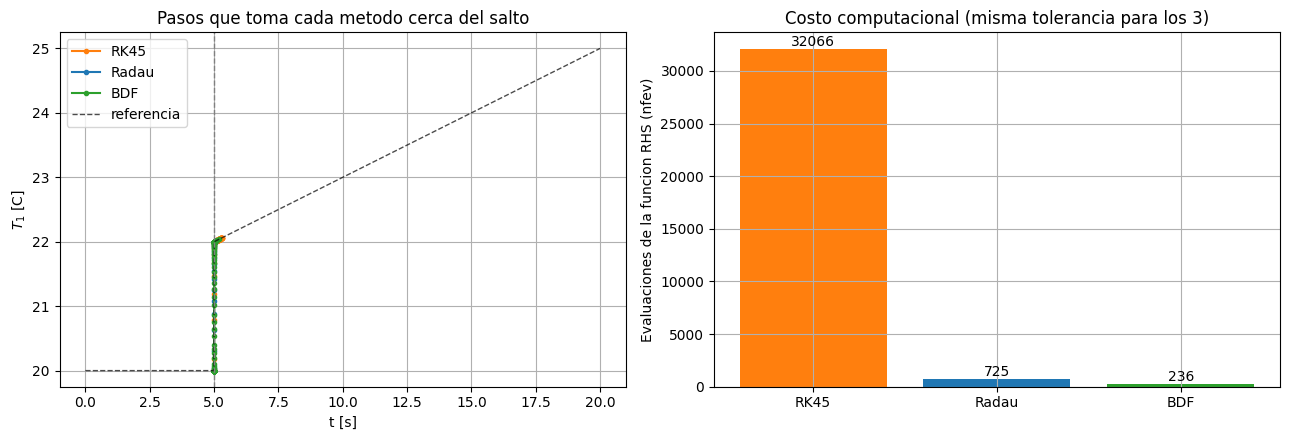

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for m, color in zip(metodos, ['tab:orange', 'tab:blue', 'tab:green']):
    sol = resultados[m]
    ventana = (sol.t >= t0_jump - 0.02) & (sol.t <= t0_jump + 0.3)
    ax.plot(sol.t[ventana], sol.y[0][ventana], 'o-', ms=3, color=color, label=m)
ax.plot(t_plot, y_ref[0], 'k--', lw=1, alpha=0.7, label='referencia')
ax.axvline(t0_jump, color='gray', ls='--', lw=1)
ax.set_xlabel('t [s]'); ax.set_ylabel('$T_1$ [C]')
ax.set_title('Pasos que toma cada metodo cerca del salto')
ax.legend()

ax = axes[1]
nfev_vals = [resultados[m].nfev for m in metodos]
bars = ax.bar(metodos, nfev_vals, color=['tab:orange', 'tab:blue', 'tab:green'])
ax.set_ylabel('Evaluaciones de la funcion RHS (nfev)')
ax.set_title('Costo computacional (misma tolerancia para los 3)')
for b, v in zip(bars, nfev_vals):
    ax.text(b.get_x()+b.get_width()/2, v, str(v), ha='center', va='bottom')

plt.tight_layout(); plt.show()


## 8. Tabla resumen

| Método | Tipo | ¿Necesita $h$ pequeño para el salto? | Comportamiento con $h$ grande |
|---|---|---|---|
| Euler explícito (paso fijo) | Explícito, orden 1 | Sí, $h < 2/\vert\lambda_{rápido}\vert$ | Oscila; si $h$ es muy grande, la oscilación **crece sin límite** |
| RK4 (paso fijo) | Explícito, orden 4 | Sí, $h \lesssim 2.785/\vert\lambda_{rápido}\vert$ | **Diverge monótonamente** (no oscila, pero también falla) |
| RK45 (adaptativo) | Explícito, orden 4-5 | El solver se autoajusta, pero a costa de muchísimos pasos pequeños | No diverge, pero es muy costoso cerca del salto |
| Euler implícito | Implícito, orden 1, A-estable | No | Estable siempre; error de truncamiento si $h$ es grande, pero **sin oscilación** |
| Radau / BDF | Implícito, alto orden, A-estable / stiffly stable | No | Estable y eficiente: pasos grandes en zonas lentas, pequeños solo donde hace falta |

## 9. Conclusión pedagógica

1. La **rigidez** de un sistema no es un problema en sí misma si la solución es suave: el problema aparece cuando algo (aquí, un salto en la forzante) excita el modo rápido.
2. Un método **explícito** de paso fijo necesita resolver el modo *más rápido* del sistema, aunque ese modo casi no le importe a la respuesta física que te interesa (aquí, la temperatura del baño $T_2$). Esto obliga a usar un $h$ absurdamente pequeño solo para no volverse inestable.
3. Un método **implícito** resuelve una ecuación algebraica en cada paso (aquí, un sistema lineal) en lugar de solo evaluar la derivada; a cambio, es estable para cualquier $h$, sin importar cuán rígido sea el sistema.
4. En la práctica, para sistemas rígidos siempre conviene usar un integrador implícito (`'Radau'`, `'BDF'`, o `'LSODA'` que cambia automáticamente entre explícito e implícito).


## 10. Ejercicios propuestos

1. **Rampa en vez de escalón.** Reemplaza `Q(t)` por una transición suave (por ejemplo, una rampa lineal de duración $\Delta t_{rampa}$ entre $0$ y $Q_0$, o una tangente hiperbólica). Repite el experimento de Euler explícito con `h = 0.0025 s`. ¿A partir de qué $\Delta t_{rampa}$ desaparecen las oscilaciones? Relaciona tu respuesta con el contenido de frecuencias del salto.

2. **Paso crítico teórico vs numérico.** Deriva analíticamente $h_{crit}$ para Euler explícito en función de $UA$, $C_1$ y $C_2$, y compáralo con el valor que obtienes probando numéricamente distintos $h$ (busca el $h$ más grande para el cual la solución no diverge en $t\in[0,20]$s).

3. **Cambia la relación de capacidades.** Prueba $C_1 = 0.5$ J/K (en vez de 0.05) y repite todo el análisis. ¿Cómo cambia el número de rigidez? ¿Cómo cambia $h_{crit}$?

4. **RK2 (punto medio).** Implementa RK2 de paso fijo y encuentra su función de estabilidad $R(z)$ y su límite en el eje real. ¿Su comportamiento cerca de la inestabilidad se parece más a Euler (oscilante) o a RK4 (monótono)?

5. **El clásico problema de Robertson.** Busca las ecuaciones del "problema de Robertson" (una cinética química con tres especies y constantes de reacción muy distintas, un ejemplo canónico de sistema rígido en la literatura de métodos numéricos). Intégralo con `RK45` y con `Radau`, y compara `nfev` como hicimos en la Sección 7.

6. **Pérdidas del baño al ambiente.** Añade un término $-h_{amb}(T_2 - T_{amb})$ a la ecuación de $T_2$ (pérdida de calor del baño hacia el entorno). Recalcula los autovalores de la nueva matriz $A$ (ya no tendrá un autovalor exactamente cero) y repite el análisis de estabilidad.
